# Shor's Algorithm — Breaking secp256k1
### Quantum ECDLP Attack on Ethereum's Signature Scheme

### 1️⃣ Problem Statement

Ethereum uses **ECDSA over secp256k1** for transaction signatures:
- Private key: random scalar $k \in [1, N-1]$
- Public key: $Q = k \cdot G$ (elliptic curve point multiplication)
- The **Elliptic Curve Discrete Logarithm Problem (ECDLP)**: given $Q$ and $G$, find $k$

$$
\text{Given } Q = k \cdot G, \text{ find } k
$$

| Complexity | Classical (Pollard's rho) | Quantum (Shor) |
|---|---|---|
| Full secp256k1 ($N \approx 2^{256}$) | $O(2^{128})$ | $O(n^3)$ where $n = 256$ |
| Toy secp256k1 ($N = 9$) | $O(3)$ | $O(1)$ |

This notebook demonstrates Shor's algorithm on a **toy secp256k1** curve ($p=17$, order $N=9$) to show how quantum computers break ECDSA step by step.
The mathematical structure is identical to the real attack.

### 2️⃣ Shor's ECDLP Algorithm — Overview

Classical Shor's algorithm finds the **period** of a function. For ECDLP, we define a 2D periodic function:

$$
f(a, b) = a \cdot G + b \cdot Q = (a + b \cdot k) \cdot G
$$

This function has a **period lattice** $\langle (N, 0),\; (k, -1) \rangle$ — meaning $f(a, b) = f(a + N, b) = f(a + k, b - 1)$.

**Algorithm steps:**

1. **Superposition**: prepare $|a\rangle|b\rangle$ in uniform superposition over $\mathbb{Z}_N \times \mathbb{Z}_N$
2. **Oracle**: evaluate $f(a,b)$ into an ancilla register, then measure the ancilla → collapses to a **coset state**
3. **2D QFT**: apply quantum Fourier transform modulo $N$ on both registers
4. **Measure** $(s, t)$ — the frequency-domain output
5. **Recover $k$**: compute $k \equiv s^{-1} \cdot t \pmod{N}$ when $\gcd(s, N) = 1$

The key insight: after measuring the ancilla, the state collapses to:

$$
|\psi\rangle = \frac{1}{\sqrt{N}} \sum_{b=0}^{N-1} |(p_0 - b \cdot k) \bmod N\rangle_a \;|b\rangle_b
$$

The 2D QFT then reveals the hidden linear relationship $t \equiv s \cdot k \pmod{N}$.

### 3️⃣ Imports

In [12]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from math import gcd

In [13]:
sys.path.append('..')

In [14]:
from lib.shor import (
    ORDER, build_coset_state, modular_dft_2d, sample_from_dft,
    decode_k, build_circuit, shor_ecdlp,
)
from lib.secp256k1_toy import (
    G, P, scalar_mult, generate_keypair, INFINITY,
)

### 4️⃣ The Toy Curve

Our toy secp256k1: $y^2 = x^3 + 7 \pmod{17}$

| Parameter | Toy | Real secp256k1 |
|---|---|---|
| Field prime $p$ | 17 | $2^{256} - 2^{32} - 977$ |
| Generator $G$ | $(12, 1)$ | (a 256-bit point) |
| Subgroup order $N$ | 9 | $\approx 2^{256}$ |
| Key space | 8 keys | $\approx 2^{256}$ keys |

In [15]:
print(f"Curve: y\u00b2 = x\u00b3 + 7  (mod {P})")
print(f"Generator G = {G}")
print(f"Subgroup order = {ORDER}")
print("\nSubgroup \u27e8G\u27e9:")
for i in range(1, ORDER + 1):
    pt = scalar_mult(i, G)
    label = "\u221e" if pt is INFINITY else str(pt)
    print(f"  {i:2d} \u00b7 G = {label}")

Curve: y² = x³ + 7  (mod 17)
Generator G = (12, 1)
Subgroup order = 9

Subgroup ⟨G⟩:
   1 · G = (12, 1)
   2 · G = (1, 12)
   3 · G = (5, 9)
   4 · G = (2, 7)
   5 · G = (2, 10)
   6 · G = (5, 8)
   7 · G = (1, 5)
   8 · G = (12, 16)
   9 · G = ∞


### 5️⃣ Key Generation (the target)

We generate a random keypair and then try to recover the private key using Shor's algorithm.

In [16]:
# Generate a random keypair
k_secret, Q = generate_keypair(n=ORDER)
print(f"Private key (SECRET): k = {k_secret}")
print(f"Public key:           Q = {Q}")
print(f"Verify: {k_secret} \u00b7 G = {scalar_mult(k_secret, G)} == {Q} \u2713")
assert scalar_mult(k_secret, G) == Q

Private key (SECRET): k = 5
Public key:           Q = (2, 10)
Verify: 5 · G = (2, 10) == (2, 10) ✓


### 6️⃣ Step 1 & 2 — Coset State Preparation

After the oracle evaluates $f(a,b) = a \cdot G + b \cdot Q$ and we measure the ancilla to get some point $p_0 \cdot G$, the joint register collapses to:

$$
|\psi\rangle = \frac{1}{\sqrt{N}} \sum_{b=0}^{N-1} |(p_0 - b \cdot k) \bmod N\rangle_a \;|b\rangle_b
$$

Each row has exactly one nonzero entry, forming a **diagonal stripe** pattern whose slope encodes $k$.

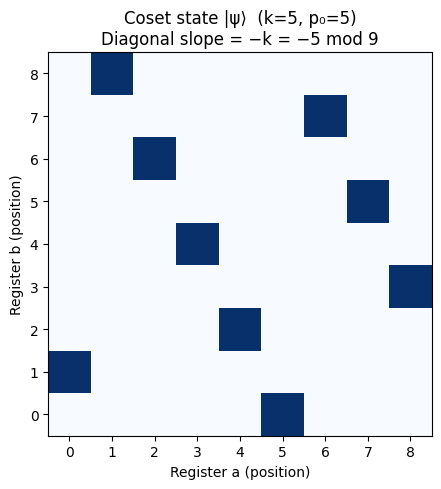

Nonzero entries (a, b):
  b=0, a=5  →  a + b·k = 5 + 0·5 = 5 ≡ 5 (mod 9)
  b=1, a=0  →  a + b·k = 0 + 1·5 = 5 ≡ 5 (mod 9)
  b=2, a=4  →  a + b·k = 4 + 2·5 = 5 ≡ 5 (mod 9)
  b=3, a=8  →  a + b·k = 8 + 3·5 = 5 ≡ 5 (mod 9)
  b=4, a=3  →  a + b·k = 3 + 4·5 = 5 ≡ 5 (mod 9)
  b=5, a=7  →  a + b·k = 7 + 5·5 = 5 ≡ 5 (mod 9)
  b=6, a=2  →  a + b·k = 2 + 6·5 = 5 ≡ 5 (mod 9)
  b=7, a=6  →  a + b·k = 6 + 7·5 = 5 ≡ 5 (mod 9)
  b=8, a=1  →  a + b·k = 1 + 8·5 = 5 ≡ 5 (mod 9)


In [17]:
p0 = np.random.randint(0, ORDER)
psi = build_coset_state(k_secret, p0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(np.abs(psi)**2, cmap='Blues', origin='lower')
ax.set_xlabel('Register a (position)')
ax.set_ylabel('Register b (position)')
ax.set_title(f'Coset state |\u03c8\u27e9  (k={k_secret}, p\u2080={p0})\n'
             f'Diagonal slope = \u2212k = \u2212{k_secret} mod {ORDER}')
ax.set_xticks(range(ORDER))
ax.set_yticks(range(ORDER))
plt.tight_layout()
plt.show()

print("Nonzero entries (a, b):")
for b in range(ORDER):
    a = (p0 - b * k_secret) % ORDER
    print(f"  b={b}, a={a}  \u2192  a + b\u00b7k = {a} + {b}\u00b7{k_secret} = {(a + b * k_secret) % ORDER} \u2261 {p0} (mod {ORDER})")

### 7️⃣ Step 3 — 2D Quantum Fourier Transform

We apply the QFT modulo $N$ independently on each register. The 2D QFT converts the spatial coset pattern into frequency-domain peaks:

$$
F[t, s] = \frac{1}{N} \sum_{b,a} \psi[b,a] \cdot \omega^{-(s \cdot a + t \cdot b)}, \quad \omega = e^{2\pi i / N}
$$

The peaks appear where $t \equiv s \cdot k \pmod{N}$ — exactly the hidden linear relationship we want to extract.

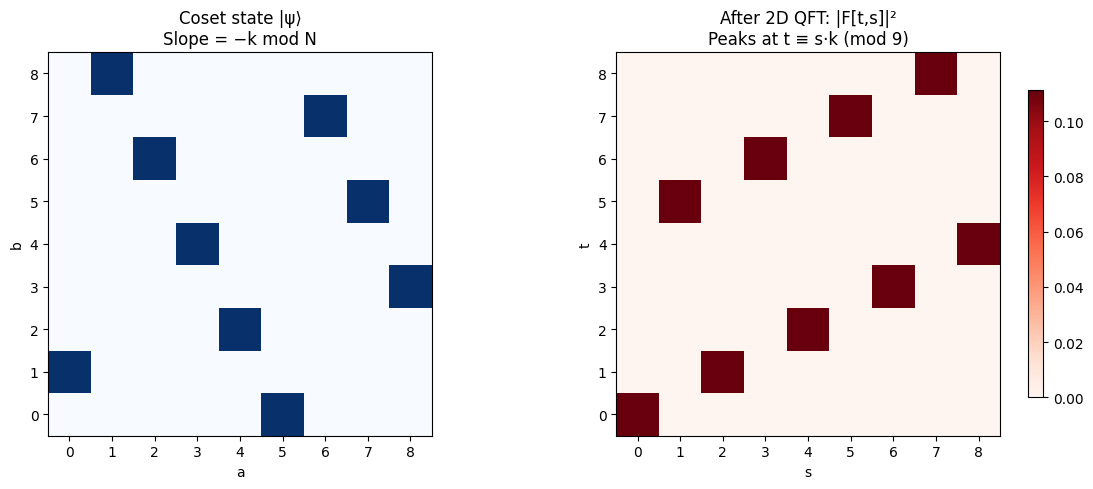

Peak positions (s, t) where |F|² > 0:
  (s=0, t=0)  t ≡ 0·5 = 0 mod 9  ✓
  (s=1, t=5)  t ≡ 1·5 = 5 mod 9  ✓
  (s=2, t=1)  t ≡ 2·5 = 1 mod 9  ✓
  (s=3, t=6)  t ≡ 3·5 = 6 mod 9  ✓
  (s=4, t=2)  t ≡ 4·5 = 2 mod 9  ✓
  (s=5, t=7)  t ≡ 5·5 = 7 mod 9  ✓
  (s=6, t=3)  t ≡ 6·5 = 3 mod 9  ✓
  (s=7, t=8)  t ≡ 7·5 = 8 mod 9  ✓
  (s=8, t=4)  t ≡ 8·5 = 4 mod 9  ✓


In [18]:
F = modular_dft_2d(psi)
probs = np.abs(F)**2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Coset state
axes[0].imshow(np.abs(psi)**2, cmap='Blues', origin='lower')
axes[0].set_xlabel('a')
axes[0].set_ylabel('b')
axes[0].set_title('Coset state |\u03c8\u27e9\nSlope = \u2212k mod N')
axes[0].set_xticks(range(ORDER))
axes[0].set_yticks(range(ORDER))

# QFT output
im = axes[1].imshow(probs, cmap='Reds', origin='lower')
axes[1].set_xlabel('s')
axes[1].set_ylabel('t')
axes[1].set_title(f'After 2D QFT: |F[t,s]|\u00b2\nPeaks at t \u2261 s\u00b7k (mod {ORDER})')
axes[1].set_xticks(range(ORDER))
axes[1].set_yticks(range(ORDER))
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

# Verify peaks are at t = s*k mod N
print("Peak positions (s, t) where |F|\u00b2 > 0:")
for s in range(ORDER):
    for t in range(ORDER):
        if probs[t, s] > 1e-10:
            expected_t = (s * k_secret) % ORDER
            match = "\u2713" if t == expected_t else "\u2717"
            print(f"  (s={s}, t={t})  t \u2261 {s}\u00b7{k_secret} = {expected_t} mod {ORDER}  {match}")

### 8️⃣ Step 4 & 5 — Measurement and Key Recovery

Each measurement yields a pair $(s, t)$ from the QFT output. Since the peaks satisfy $t \equiv s \cdot k \pmod{N}$:

$$
k \equiv s^{-1} \cdot t \pmod{N} \quad \text{when } \gcd(s, N) = 1
$$

We take the most-voted candidate across many shots.

In [19]:
# Sample from the QFT probability distribution
counts = sample_from_dft(F, shots=4096)

# Decode
print("Sample measurements and key recovery:\n")
print(f"{'(s, t)':>10}  {'freq':>5}  {'gcd(s,N)':>8}  {'k = s\u207b\u00b9\u00b7t mod N':>18}")
print("-" * 50)

for (s, t), freq in sorted(counts.items(), key=lambda x: -x[1])[:15]:
    g = gcd(s, ORDER)
    if s == 0 or t == 0 or g != 1:
        k_str = "skip"
    else:
        k_cand = (pow(s, -1, ORDER) * t) % ORDER
        k_str = str(k_cand)
    print(f"  ({s}, {t}){freq:>8}  {g:>8}  {k_str:>18}")

k_recovered = decode_k(counts)
print("\n\u2501\u2501\u2501\u2501\u2501\u2501\u2501\u2501\u2501\u2501\u2501\u2501\u2501\u2501\u2501\u2501\u2501\u2501\u2501\u2501")
print(f"Recovered k = {k_recovered}")
print(f"Secret k    = {k_secret}")
print(f"Match: {k_recovered == k_secret}  {'\u2705' if k_recovered == k_secret else '\u274c'}")

Sample measurements and key recovery:

    (s, t)   freq  gcd(s,N)     k = s⁻¹·t mod N
--------------------------------------------------
  (8, 4)     481         1                   5
  (3, 6)     467         3                skip
  (4, 2)     463         1                   5
  (7, 8)     460         1                   5
  (1, 5)     460         1                   5
  (2, 1)     459         1                   5
  (6, 3)     459         3                skip
  (0, 0)     429         9                skip
  (5, 7)     418         1                   5

━━━━━━━━━━━━━━━━━━━━
Recovered k = 5
Secret k    = 5
Match: True  ✅


### 9️⃣ Full Attack — All Keys

Let's verify the attack works for every possible private key in the toy curve.

In [20]:
print(f"Shor ECDLP attack on all {ORDER - 1} possible private keys:\n")
successes = 0
for k_test in range(1, ORDER):
    Q_test = scalar_mult(k_test, G)
    k_rec, _, _ = shor_ecdlp(Q_test, shots=4096)
    ok = k_rec == k_test
    successes += ok
    symbol = "\u2705" if ok else "\u274c"
    print(f"  k={k_test}  Q={str(Q_test):>10}  \u2192  recovered={k_rec}  {symbol}")

print(f"\nSuccess rate: {successes}/{ORDER - 1} = {successes/(ORDER-1):.0%}")

Shor ECDLP attack on all 8 possible private keys:

  k=1  Q=   (12, 1)  →  recovered=1  ✅
  k=2  Q=   (1, 12)  →  recovered=2  ✅
  k=3  Q=    (5, 9)  →  recovered=3  ✅
  k=4  Q=    (2, 7)  →  recovered=4  ✅
  k=5  Q=   (2, 10)  →  recovered=5  ✅
  k=6  Q=    (5, 8)  →  recovered=6  ✅
  k=7  Q=    (1, 5)  →  recovered=7  ✅
  k=8  Q=  (12, 16)  →  recovered=8  ✅

Success rate: 8/8 = 100%


### \ud83d\udd1f Measurement Distribution

Visualize the measurement histogram. Green bars are outcomes that correctly recover $k$.

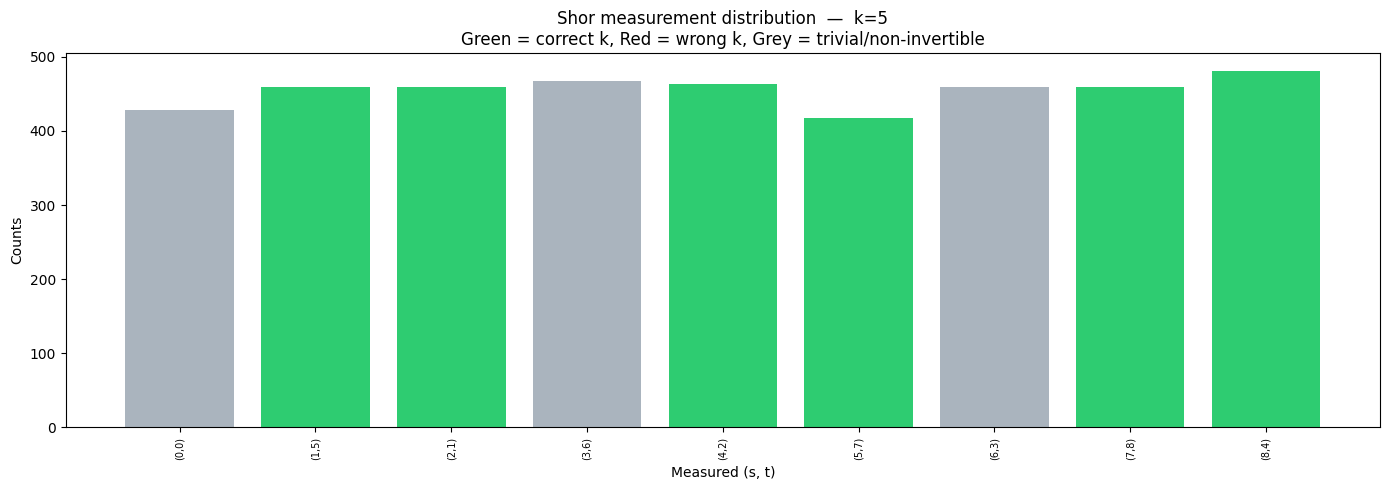

Success probability: 2741/4096 = 66.9%


In [21]:
# Use the counts from the single-key attack above
labels = [f"({s},{t})" for (s, t) in sorted(counts.keys())]
freqs = [counts[k] for k in sorted(counts.keys())]

# Color: green if this (s,t) decodes to the correct k
colors = []
for (s, t) in sorted(counts.keys()):
    if s == 0 or t == 0 or gcd(s, ORDER) != 1:
        colors.append('#aab4be')
    else:
        k_c = (pow(s, -1, ORDER) * t) % ORDER
        colors.append('#2ecc71' if k_c == k_secret else '#e74c3c')

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(labels)), freqs, color=colors)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_xlabel('Measured (s, t)')
ax.set_ylabel('Counts')
ax.set_title(f'Shor measurement distribution  \u2014  k={k_secret}\n'
             f'Green = correct k, Red = wrong k, Grey = trivial/non-invertible')
plt.tight_layout()
plt.show()

total = sum(freqs)
correct = sum(f for (s, t), f in counts.items()
              if s != 0 and t != 0 and gcd(s, ORDER) == 1
              and (pow(s, -1, ORDER) * t) % ORDER == k_secret)
print(f"Success probability: {correct}/{total} = {correct/total:.1%}")

### \ud83d\udd1f Quantum Circuit Diagram

This is the Qiskit circuit that implements the algorithm. It uses a base-2 QFT (inverse QFT on $\lceil\log_2 N\rceil$ qubits per register). For the toy case, the exact modular DFT simulation above gives perfect results; the base-2 circuit introduces spectral leakage when $N$ is not a power of 2.

Qubits: 8  (2 × 4 per register)
Depth:  10
Gates:  {'cp': 12, 'h': 8, 'measure': 8, 'swap': 4, 'barrier': 2, 'initialize': 1}


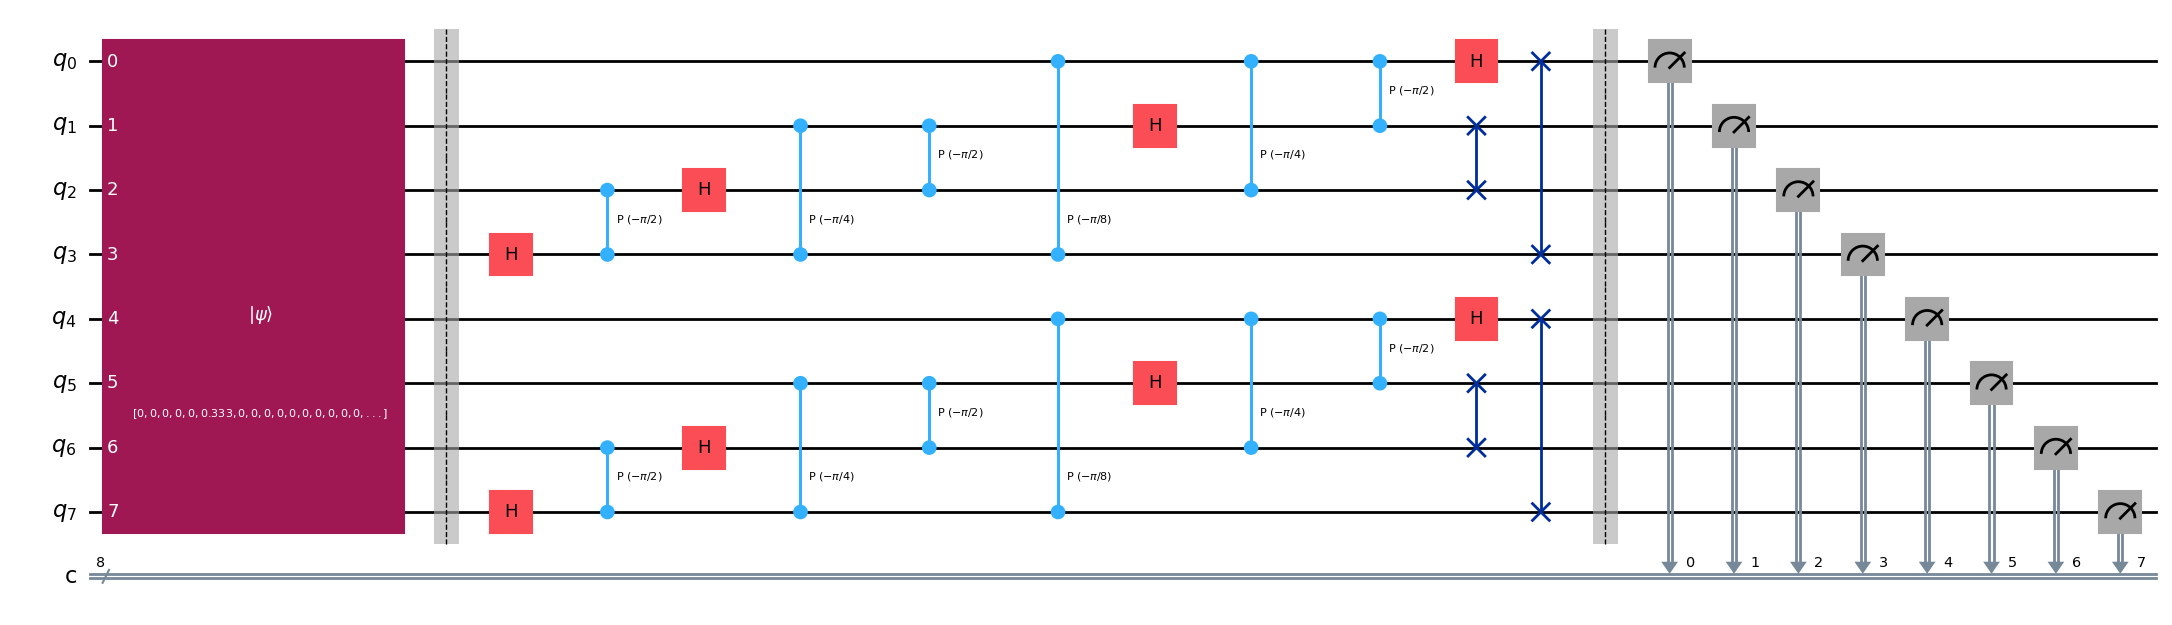

In [22]:
qc = build_circuit(k_secret, p0)
print(f"Qubits: {qc.num_qubits}  (2 \u00d7 {qc.num_qubits // 2} per register)")
print(f"Depth:  {qc.depth()}")
print(f"Gates:  {dict(qc.count_ops())}")
qc.draw('mpl', fold=80)

### \ud83d\udd1f Scaling to Real secp256k1

| Parameter | Toy secp256k1 | Real secp256k1 (Ethereum) |
|---|---|---|
| Field prime $p$ | 17 | $2^{256} - 2^{32} - 977$ |
| Group order $N$ | 9 | $\approx 2^{256}$ |
| Private key space | 8 values | $\approx 2^{256}$ |
| Qubits needed | 8 | $\sim 2{,}048$ logical ($\sim 10^6$ physical with QEC) |
| QFT size | $9 \times 9$ | $2^{256} \times 2^{256}$ |
| Toffoli gates | $< 100$ | $\sim 10^{11}$ |
| Estimated runtime | microseconds | hours to days (on future hardware) |

**Why this matters for Ethereum:**
- Shor's algorithm breaks ECDSA in **polynomial time** — the security drops from $2^{128}$ to essentially zero
- Unlike Grover (which only halves the security level), Shor **completely breaks** the asymmetric crypto
- Every Ethereum address that has ever signed a transaction exposes its public key, making it vulnerable

**Current status:**
- The largest number factored by Shor's algorithm on real hardware is 21 (2012, 10 qubits)
- Breaking secp256k1 requires $\sim 2{,}048$ **error-corrected** logical qubits
- Estimated timeline: 10-20+ years for cryptographically relevant quantum computers
- **Post-quantum alternatives** (CRYSTALS-Dilithium, FALCON, SPHINCS+) are already standardized by NIST

**What this notebook proves:**
- The 2D coset + QFT approach correctly extracts the private key from the public key
- The algorithm is **deterministic** in the frequency domain — all nonzero peaks encode $k$
- The attack scales polynomially with key size, unlike brute force